In [14]:
import os
os.chdir("/Users/dulanjanwijenayake/projects/pv_forecast_30d")
print(os.getcwd())

/Users/dulanjanwijenayake/projects/pv_forecast_30d


In [15]:
import os
os.getcwd()

'/Users/dulanjanwijenayake/projects/pv_forecast_30d'

In [27]:
import pandas as pd

df = pd.read_parquet("data/interim/farm_2107/farm2107_elec_irradiance_15min.parquet")
print(df.head())
print(df.info())

          measured_on  p_ac_plant_kw  pv_power_norm  poa_irradiance
0 2017-11-01 07:00:00       0.000000       0.000000             0.0
1 2017-11-01 07:15:00       0.000000       0.000000             0.0
2 2017-11-01 07:30:00       0.050667       0.000057             NaN
3 2017-11-01 07:45:00       7.374333       0.008258             NaN
4 2017-11-01 08:00:00      29.918333       0.033503             NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245540 entries, 0 to 245539
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   measured_on     245540 non-null  datetime64[ns]
 1   p_ac_plant_kw   240328 non-null  float64       
 2   pv_power_norm   240328 non-null  float64       
 3   poa_irradiance  225066 non-null  float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 7.5 MB
None


In [21]:
import pandas as pd

df = pd.read_parquet("data/interim/farm_2107/farm2107_electrical_15min.parquet")
day_sample = df[df["p_ac_plant_kw"] > 0].sample(10)
print(day_sample)
print(df.head())
print(df.tail())
print(df.info())

               measured_on  p_ac_plant_kw  pv_power_norm
145477 2021-12-25 09:15:00      99.115333       0.110991
55812  2019-06-05 09:00:00     335.848000       0.376090
155110 2022-04-04 17:30:00     211.962667       0.237360
128286 2021-06-29 07:30:00      88.223000       0.098794
701    2017-11-08 07:15:00       5.744667       0.006433
124638 2021-05-22 07:30:00     115.770000       0.129642
91133  2020-06-07 07:15:00      83.063667       0.093016
200375 2023-07-20 05:45:00       0.008333       0.000009
166502 2022-08-01 09:30:00     225.388667       0.252395
164611 2022-07-12 16:45:00     331.687000       0.371430
          measured_on  p_ac_plant_kw  pv_power_norm
0 2017-11-01 00:00:00            0.0            0.0
1 2017-11-01 00:15:00            0.0            0.0
2 2017-11-01 00:30:00            0.0            0.0
3 2017-11-01 00:45:00            0.0            0.0
4 2017-11-01 01:00:00            0.0            0.0
               measured_on  p_ac_plant_kw  pv_power_norm
2455

,measured_on,p_ac_plant_kw,pv_power_norm,poa_irradiance
measured_on,1.000000,0.042254,0.042254,0.025444
p_ac_plant_kw,0.042254,1.000000,1.000000,0.960325
pv_power_norm,0.042254,1.000000,1.000000,0.960325
poa_irradiance,0.025444,0.960325,0.960325,1.000000


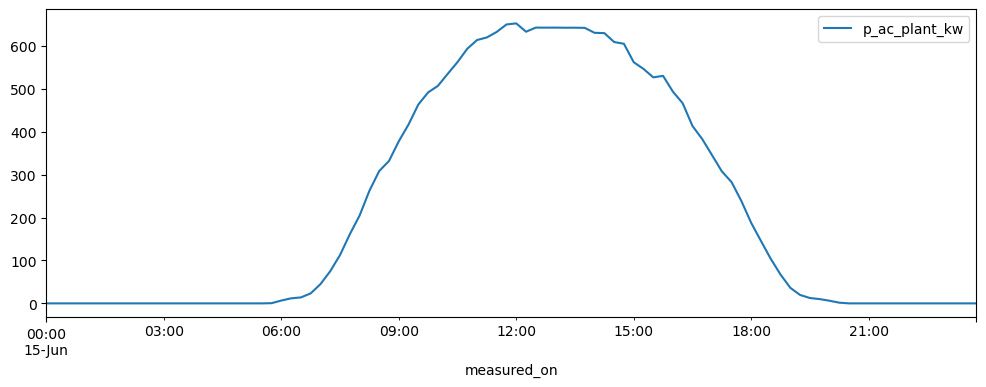

In [26]:
df.loc[df["p_ac_plant_kw"].idxmax()]
df_day = df[df["measured_on"].dt.date == pd.to_datetime("2021-06-15").date()]
df_day.plot(x="measured_on", y="p_ac_plant_kw", figsize=(12,4))
df_core = pd.read_parquet("data/interim/farm_2107/farm2107_elec_irradiance_15min.parquet")
df_core.head()
df_core.dropna().corr()


In [28]:
df = pd.read_parquet("data/interim/farm_2107/farm2107_elec_irradiance_15min.parquet")
df["measured_on"].min(), df["measured_on"].max()

(Timestamp('2017-11-01 07:00:00'), Timestamp('2024-11-01 23:45:00'))